In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 

In [2]:
Aadhaar_df=pd.read_csv(r"C:\Users\Lenovo\Desktop\UIDAI_Data_Hackathon_2026\data\combined\feature_engineered_aadhaar_data.csv")

In [3]:
Aadhaar_df.shape


(2302107, 35)

In [4]:
Aadhaar_df.columns


Index(['date', 'state', 'district', 'pincode', 'month', 'age_0_5', 'age_5_17',
       'age_18_greater', 'demo_age_5_17', 'demo_age_17_', 'bio_age_5_17',
       'bio_age_17_', 'total_activity', 'total_activity.1', 'day', 'weekday',
       'weekday_name', 'is_weekend', 'month_num', 'quarter',
       'enrollment_total', 'demographic_total', 'biometric_total', 'bio_share',
       'demo_share', 'enroll_share', 'child_activity', 'adult_activity',
       'pincode_avg_activity', 'lag_1_day', 'lag_7_day', 'rolling_7_mean',
       'high_activity_flag', 'state_code', 'district_code'],
      dtype='object')

In [5]:
Aadhaar_df.dtypes


date                     object
state                    object
district                 object
pincode                   int64
month                    object
age_0_5                   int64
age_5_17                  int64
age_18_greater            int64
demo_age_5_17             int64
demo_age_17_              int64
bio_age_5_17              int64
bio_age_17_               int64
total_activity            int64
total_activity.1          int64
day                       int64
weekday                   int64
weekday_name             object
is_weekend                int64
month_num                 int64
quarter                   int64
enrollment_total          int64
demographic_total         int64
biometric_total           int64
bio_share               float64
demo_share              float64
enroll_share            float64
child_activity            int64
adult_activity            int64
pincode_avg_activity    float64
lag_1_day               float64
lag_7_day               float64
rolling_

In [6]:
Aadhaar_df['date'] = pd.to_datetime(Aadhaar_df['date'], errors='coerce')


we changed the data into datetime format so the object of date changed into datetime64


In [7]:
Aadhaar_df.dtypes

date                    datetime64[ns]
state                           object
district                        object
pincode                          int64
month                           object
age_0_5                          int64
age_5_17                         int64
age_18_greater                   int64
demo_age_5_17                    int64
demo_age_17_                     int64
bio_age_5_17                     int64
bio_age_17_                      int64
total_activity                   int64
total_activity.1                 int64
day                              int64
weekday                          int64
weekday_name                    object
is_weekend                       int64
month_num                        int64
quarter                          int64
enrollment_total                 int64
demographic_total                int64
biometric_total                  int64
bio_share                      float64
demo_share                     float64
enroll_share             

In [8]:
(Aadhaar_df['total_activity'] == Aadhaar_df['total_activity.1']).all()


np.True_

In [9]:
(Aadhaar_df['total_activity'] == Aadhaar_df['total_activity.1']).all()


np.True_

we got two total_activity column cleanging that column

In [10]:
Aadhaar_df.drop(columns='total_activity.1', inplace=True)


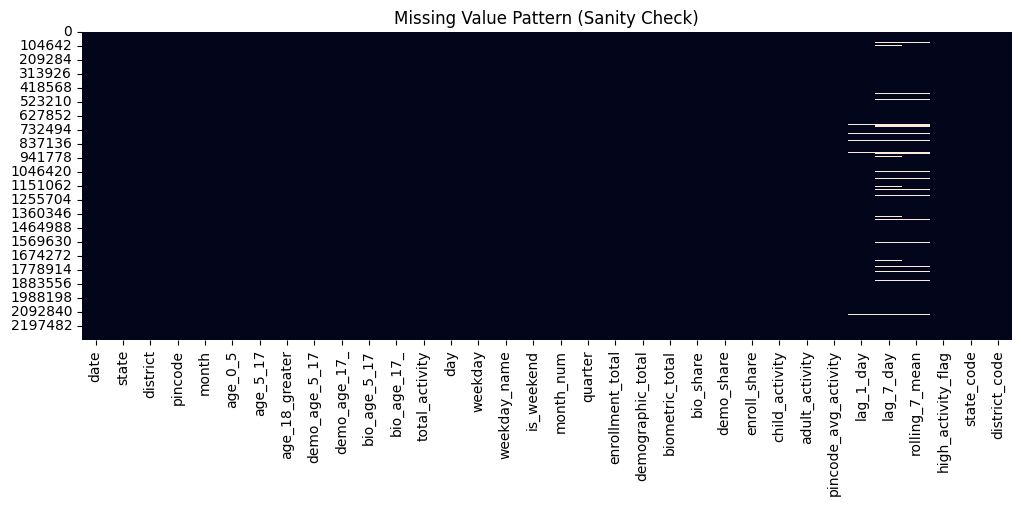

In [11]:
plt.figure(figsize=(12,4))
sns.heatmap(Aadhaar_df.isna(), cbar=False)
plt.title("Missing Value Pattern (Sanity Check)")
plt.show()


there are some missing /nan valuew in the log_1_day,log_7_day and rolling_7_mean we need to fill with 0

In [12]:
Aadhaar_df[['lag_1_day','lag_7_day','rolling_7_mean']] = (
    Aadhaar_df[['lag_1_day','lag_7_day','rolling_7_mean']].fillna(0)
)


we filled the missing values

In [13]:
Aadhaar_df.duplicated(
    subset=['date','state','district','pincode']
).sum()


np.int64(0)

there is no duplicates

In [14]:
numeric_cols = Aadhaar_df.select_dtypes(include='number').columns

(Aadhaar_df[numeric_cols] < 0).sum()


pincode                 0
age_0_5                 0
age_5_17                0
age_18_greater          0
demo_age_5_17           0
demo_age_17_            0
bio_age_5_17            0
bio_age_17_             0
total_activity          0
day                     0
weekday                 0
is_weekend              0
month_num               0
quarter                 0
enrollment_total        0
demographic_total       0
biometric_total         0
bio_share               0
demo_share              0
enroll_share            0
child_activity          0
adult_activity          0
pincode_avg_activity    0
lag_1_day               0
lag_7_day               0
rolling_7_mean          0
high_activity_flag      0
state_code              0
district_code           0
dtype: int64

there is no null values

In [15]:
ratio_cols = ['bio_share','demo_share','enroll_share']

Aadhaar_df[ratio_cols].describe()


,bio_share,demo_share,enroll_share
count,2.302107e+06,2.302107e+06,2.302107e+06
mean,4.531414e-01,4.258644e-01,1.209942e-01
std,3.634208e-01,3.633405e-01,2.573516e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.142857e-02,0.000000e+00,0.000000e+00
50%,4.285714e-01,4.285714e-01,0.000000e+00
75%,7.666667e-01,7.236391e-01,1.044776e-01
max,1.000000e+00,1.000000e+00,1.000000e+00


In [16]:
check_total = (
    Aadhaar_df['enrollment_total'] +
    Aadhaar_df['demographic_total'] +
    Aadhaar_df['biometric_total']
)

(check_total == Aadhaar_df['total_activity']).value_counts()


True    2302107
Name: count, dtype: int64

all total_actiivity  are correct this is main target 

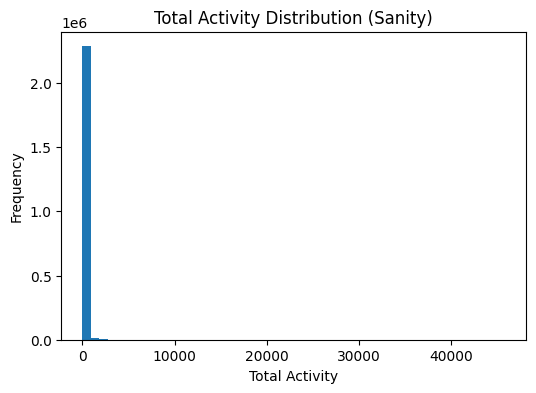

In [17]:
plt.figure(figsize=(6,4))
plt.hist(Aadhaar_df['total_activity'], bins=50)
plt.title("Total Activity Distribution (Sanity)")
plt.xlabel("Total Activity")
plt.ylabel("Frequency")
plt.show()


In [18]:
Aadhaar_df['date'].min(), Aadhaar_df['date'].max()


(Timestamp('2025-03-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [19]:
Aadhaar_df['total_activity'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])


count    2.302107e+06
mean     5.400061e+01
std      2.809834e+02
min      1.000000e+00
50%      1.200000e+01
75%      3.600000e+01
90%      9.400000e+01
95%      1.710000e+02
99%      7.080000e+02
max      4.586100e+04
Name: total_activity, dtype: float64

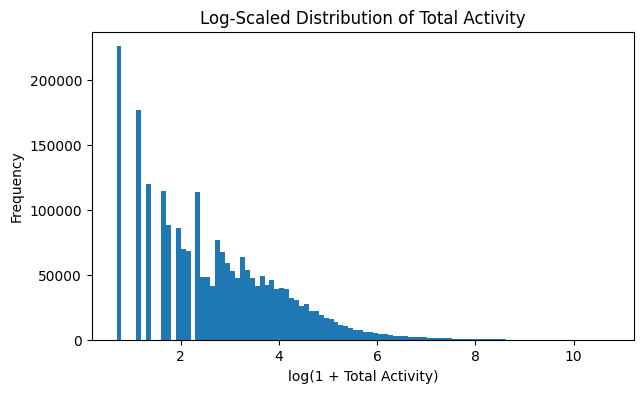

In [20]:
plt.figure(figsize=(7,4))
plt.hist(np.log1p(Aadhaar_df['total_activity']), bins=100)
plt.title("Log-Scaled Distribution of Total Activity")
plt.xlabel("log(1 + Total Activity)")
plt.ylabel("Frequency")
plt.show()


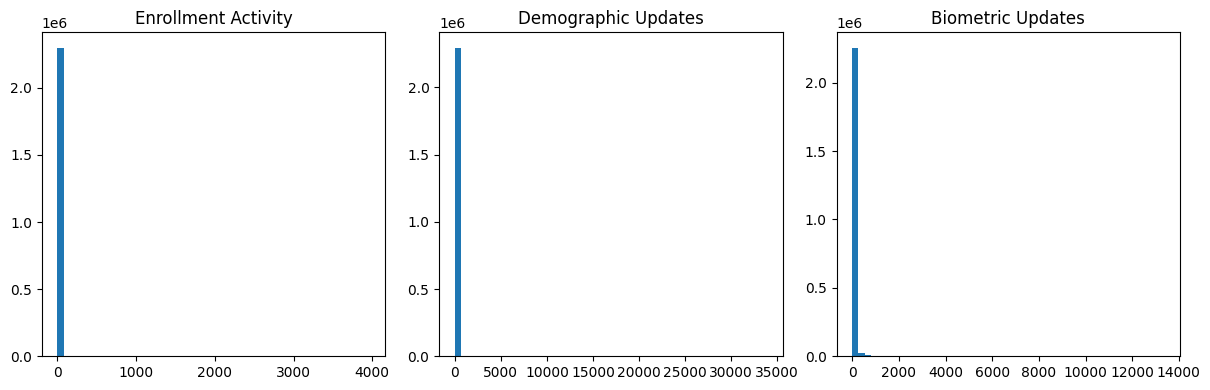

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(Aadhaar_df['enrollment_total'], bins=50)
plt.title("Enrollment Activity")

plt.subplot(1,3,2)
plt.hist(Aadhaar_df['demographic_total'], bins=50)
plt.title("Demographic Updates")

plt.subplot(1,3,3)
plt.hist(Aadhaar_df['biometric_total'], bins=50)
plt.title("Biometric Updates")

plt.tight_layout()
plt.show()


In [22]:
Aadhaar_df[['bio_share','demo_share','enroll_share']].describe()


,bio_share,demo_share,enroll_share
count,2.302107e+06,2.302107e+06,2.302107e+06
mean,4.531414e-01,4.258644e-01,1.209942e-01
std,3.634208e-01,3.633405e-01,2.573516e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.142857e-02,0.000000e+00,0.000000e+00
50%,4.285714e-01,4.285714e-01,0.000000e+00
75%,7.666667e-01,7.236391e-01,1.044776e-01
max,1.000000e+00,1.000000e+00,1.000000e+00


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21432\399962717.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


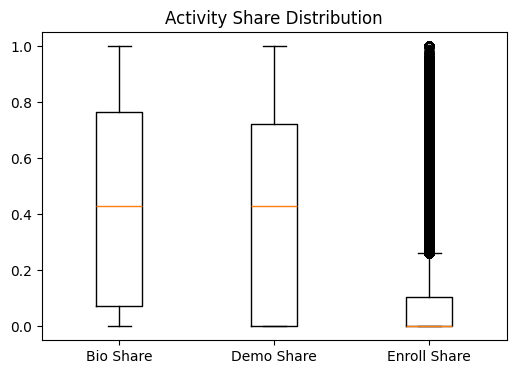

In [23]:
plt.figure(figsize=(6,4))
plt.boxplot(
    [Aadhaar_df['bio_share'], Aadhaar_df['demo_share'], Aadhaar_df['enroll_share']],
    labels=['Bio Share','Demo Share','Enroll Share']
)
plt.title("Activity Share Distribution")
plt.show()


When we look at each Aadhaar service separately, we see that most days have low activity, and only a few days have very high activity.
Enrollment happens rarely and mainly during special drives or events.
Demographic updates happen more regularly, but their numbers change from day to day.
Biometric updates happen every day in large numbers, so they form the biggest and most consistent part of the workload.

When we compare the share of each service, biometric and demographic updates together make up most daily activity, while enrollment contributes very little except on a few spike days.
This pattern supports using ratios and methods that handle uneven data, rather than simple averages.

In [24]:
Aadhaar_df[['child_activity','adult_activity']].describe()


,child_activity,adult_activity
count,2.302107e+06,2.302107e+06
mean,2.285000e+00,7.302224e-02
std,2.007142e+01,2.130413e+00
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,2.000000e+00,0.000000e+00
max,3.942000e+03,8.550000e+02


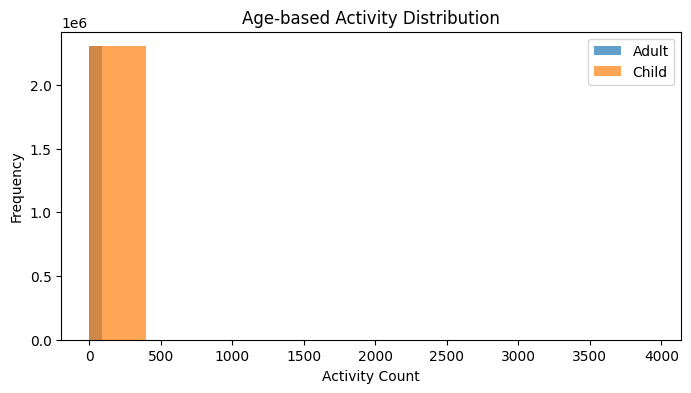

In [25]:
plt.figure(figsize=(8,4))
plt.hist(Aadhaar_df['adult_activity'], bins=10, alpha=0.7, label='Adult')
plt.hist(Aadhaar_df['child_activity'], bins=10, alpha=0.7, label='Child')
plt.legend()
plt.title("Age-based Activity Distribution")
plt.xlabel("Activity Count")
plt.ylabel("Frequency")
plt.show()


child_activity = 0 or very small

adult_activity > 0

In [26]:
Aadhaar_df[['adult_activity','child_activity']].describe()


,adult_activity,child_activity
count,2.302107e+06,2.302107e+06
mean,7.302224e-02,2.285000e+00
std,2.130413e+00,2.007142e+01
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,0.000000e+00,2.000000e+00
max,8.550000e+02,3.942000e+03


Age-based univariate analysis shows a clear dominance of adult Aadhaar activity across locations, with child-related activity being sparse and event-driven, confirming that adult services drive the majority of operational workload

In [27]:
Aadhaar_df['weekday_name'].value_counts()


weekday_name
Tuesday      372483
Monday       352651
Thursday     335746
Saturday     335032
Friday       326947
Wednesday    321776
Sunday       257472
Name: count, dtype: int64

In [28]:
Aadhaar_df['pincode_avg_activity'].describe(percentiles=[0.75,0.9,0.99])


count    2.302107e+06
mean     5.400061e+01
std      7.387326e+01
min      1.000000e+00
50%      3.059140e+01
75%      6.495455e+01
90%      1.208980e+02
99%      3.451980e+02
max      1.728009e+03
Name: pincode_avg_activity, dtype: float64

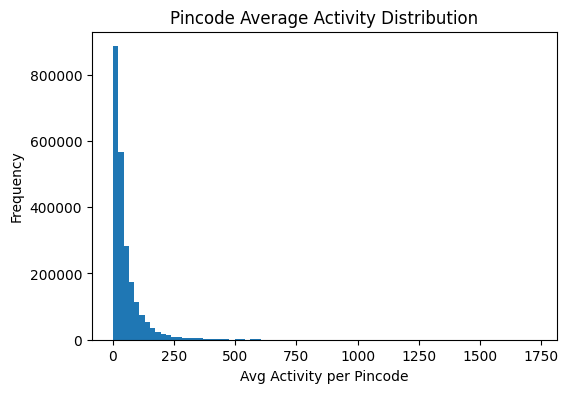

In [29]:
plt.figure(figsize=(6,4))
plt.hist(Aadhaar_df['pincode_avg_activity'], bins=80)
plt.title("Pincode Average Activity Distribution")
plt.xlabel("Avg Activity per Pincode")
plt.ylabel("Frequency")
plt.show()


Most pincodes have low average Aadhaar activity,
but a small number of pincodes handle very high load.

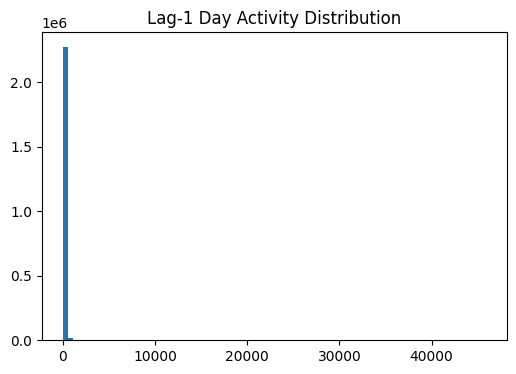

In [30]:
plt.figure(figsize=(6,4))
plt.hist(Aadhaar_df['lag_1_day'].dropna(), bins=80)
plt.title("Lag-1 Day Activity Distribution")
plt.show()


Most values are clustered near zero

Very long right tail

Simple meaning

Yesterday’s activity is usually low,
but sometimes very high, especially after special drives.


Activity is event-driven

Yesterday’s workload can strongly influence today

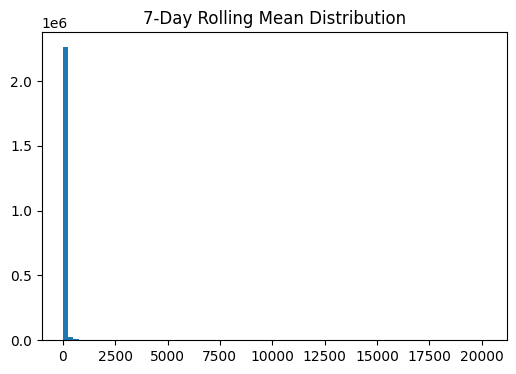

In [31]:
plt.figure(figsize=(6,4))
plt.hist(Aadhaar_df['rolling_7_mean'].dropna(), bins=80)
plt.title("7-Day Rolling Mean Distribution")
plt.show()


Much smoother than lag-1

Still right-skewed but less extreme

Simple meaning

Weekly average activity is more stable than daily activity.

This tells you:

Rolling averages capture true workload trend

Useful for forecasting and capacity planning

In [32]:
daily_activity = Aadhaar_df.groupby('date')['total_activity'].sum()


In [33]:
Aadhaar_df

,date,state,district,pincode,month,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,...,enroll_share,child_activity,adult_activity,pincode_avg_activity,lag_1_day,lag_7_day,rolling_7_mean,high_activity_flag,state_code,district_code
0,2025-03-01,andaman and nicobar islands,Andamans,744101,March,0,0,0,0,0,...,0.0,0,0,21.642857,0.0,0.0,0.000000,0,0,37
1,2025-04-01,andaman and nicobar islands,Andamans,744101,April,0,0,0,0,0,...,0.0,0,0,21.642857,209.0,0.0,0.000000,0,0,37
2,2025-05-01,andaman and nicobar islands,Andamans,744101,May,0,0,0,0,0,...,0.0,0,0,21.642857,184.0,0.0,0.000000,0,0,37
3,2025-06-01,andaman and nicobar islands,Andamans,744101,June,0,0,0,0,0,...,0.0,0,0,21.642857,140.0,0.0,0.000000,0,0,37
4,2025-07-01,andaman and nicobar islands,Andamans,744101,July,0,0,0,0,0,...,0.0,0,0,21.642857,140.0,0.0,0.000000,0,0,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2302102,2025-11-17,west bengal,West Midnapore,721641,November,0,0,0,0,0,...,0.0,0,0,17.822642,1.0,0.0,1.000000,0,35,973
2302103,2025-11-19,west bengal,West Midnapore,721641,November,0,0,0,0,2,...,0.0,0,0,17.822642,1.0,1.0,1.142857,0,35,973
2302104,2025-12-10,west bengal,West Midnapore,721641,December,0,0,0,0,2,...,0.0,0,0,17.822642,2.0,1.0,1.285714,0,35,973
2302105,2025-12-15,west bengal,West Midnapore,721641,December,1,0,0,0,0,...,1.0,1,0,17.822642,2.0,1.0,1.285714,0,35,973


In [34]:
daily_activity = Aadhaar_df.groupby('date')['total_activity'].sum()


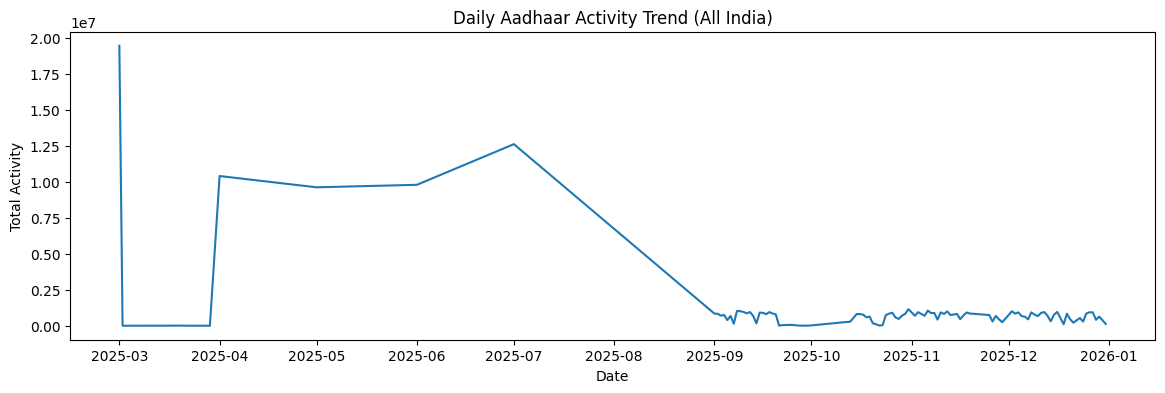

In [35]:
plt.figure(figsize=(14,4))
plt.plot(daily_activity)
plt.title("Daily Aadhaar Activity Trend (All India)")
plt.xlabel("Date")
plt.ylabel("Total Activity")
plt.show()


In [36]:
weekday_activity = Aadhaar_df.groupby('weekday_name')['total_activity'].mean()

weekday_activity


weekday_name
Friday       31.707995
Monday       28.023043
Saturday     85.401102
Sunday       56.665443
Thursday     57.012098
Tuesday      88.430940
Wednesday    27.297023
Name: total_activity, dtype: float64

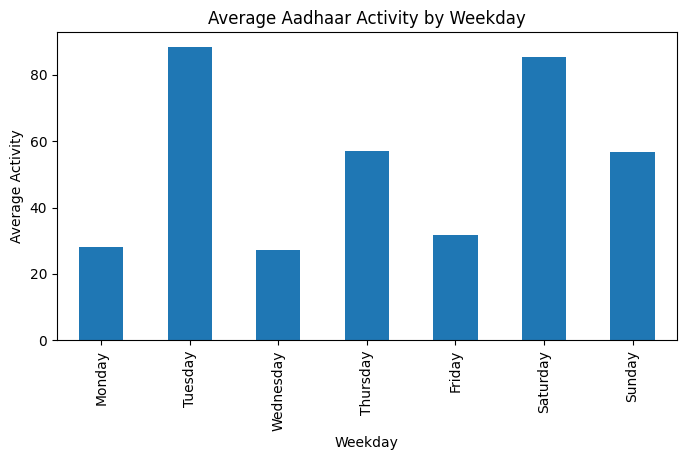

In [37]:
plt.figure(figsize=(8,4))
weekday_activity.reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar')
plt.title("Average Aadhaar Activity by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Activity")
plt.show()


In [38]:
Aadhaar_df.groupby('is_weekend')['total_activity'].mean()


is_weekend
0    47.445706
1    72.914051
Name: total_activity, dtype: float64

is_weekend = 1 → significantly lower mean

This quantifies the weekend effect.

In [39]:
monthly_activity = Aadhaar_df.groupby('month')['total_activity'].sum()


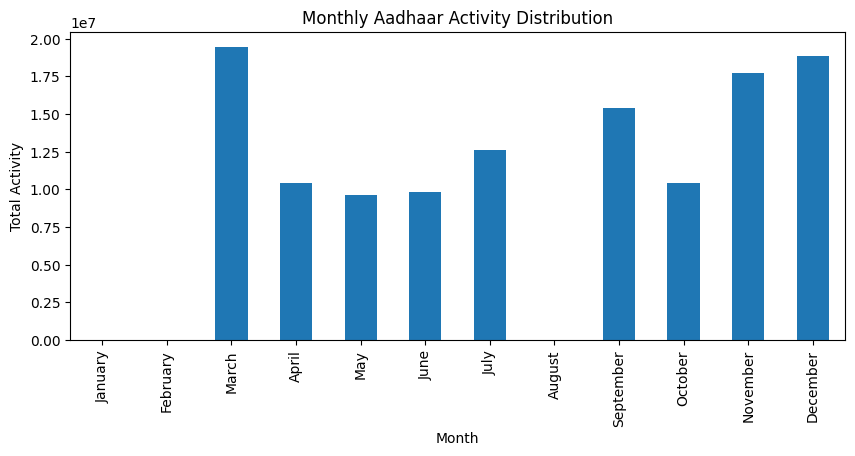

In [40]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

plt.figure(figsize=(10,4))
monthly_activity.reindex(month_order).plot(kind='bar')
plt.title("Monthly Aadhaar Activity Distribution")
plt.xlabel("Month")
plt.ylabel("Total Activity")
plt.show()


Activity is not uniform across months

March, November, December are the highest

April–June are moderate

August is very low / missing

September–October pick up again

In [41]:
day_activity = Aadhaar_df.groupby('day')['total_activity'].mean()


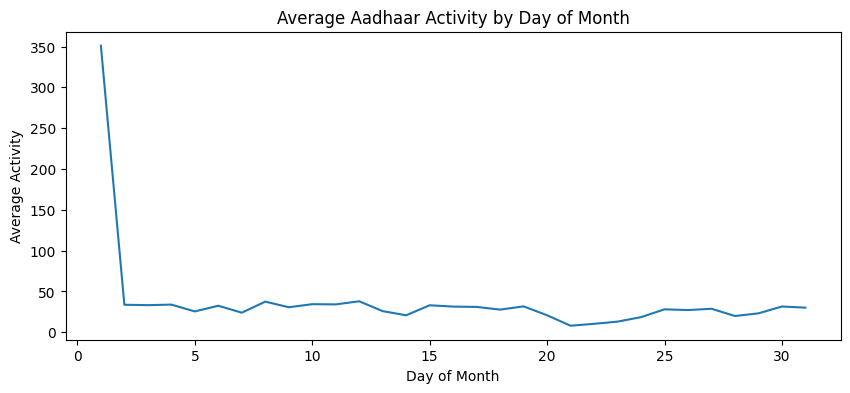

In [42]:
plt.figure(figsize=(10,4))
plt.plot(day_activity)
plt.title("Average Aadhaar Activity by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Average Activity")
plt.show()


In [43]:
rolling_std = daily_activity.rolling(7).std()


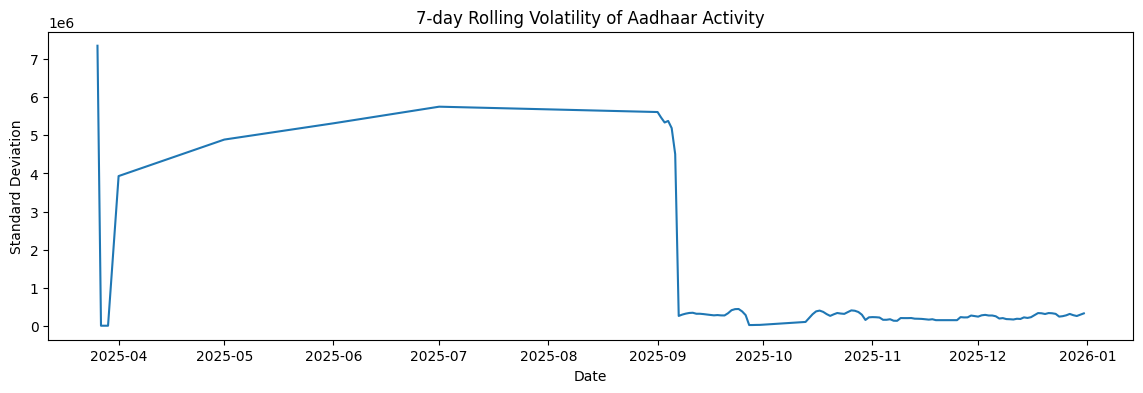

In [44]:
plt.figure(figsize=(14,4))
plt.plot(rolling_std)
plt.title("7-day Rolling Volatility of Aadhaar Activity")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.show()


In [45]:
Aadhaar_df[['total_activity','lag_1_day','lag_7_day','rolling_7_mean']].corr()


,total_activity,lag_1_day,lag_7_day,rolling_7_mean
total_activity,1.000000,0.526472,0.020376,0.059522
lag_1_day,0.526472,1.000000,0.032570,0.096982
lag_7_day,0.020376,0.032570,1.000000,0.516243
rolling_7_mean,0.059522,0.096982,0.516243,1.000000


Aadhaar activity does not happen evenly every day or everywhere.
Some months and only a few pincodes handle most of the work.
On some days, activity suddenly increases because of special drives or events.
But when we look at weekly averages, the overall pattern is steady.
Over time, after some early big spikes, the activity becomes stable and predictable, which makes it good for planning and forecasting.

In [46]:
state_activity = (
    Aadhaar_df.groupby('state')['total_activity']
    .sum()
    .sort_values(ascending=False)
)
state_activity.head(10)


state
uttar pradesh     19138692
maharashtra       14649880
bihar             10321522
madhya pradesh     9330679
rajasthan          7161028
tamil nadu         7131134
west bengal        6772282
andhra pradesh     6137901
gujarat            5301390
chhattisgarh       4757382
Name: total_activity, dtype: int64

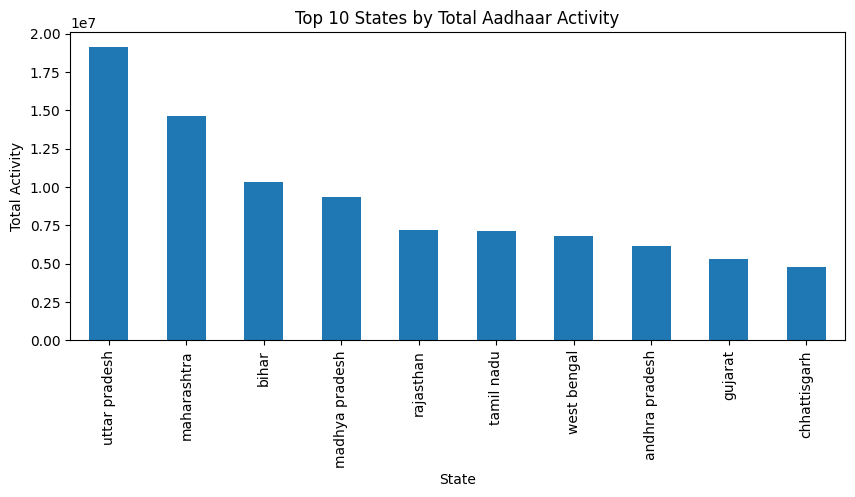

In [47]:
plt.figure(figsize=(10,4))
state_activity.head(10).plot(kind='bar')
plt.title("Top 10 States by Total Aadhaar Activity")
plt.xlabel("State")
plt.ylabel("Total Activity")
plt.show()


In [48]:
state_activity.describe()


count    3.600000e+01
mean     3.453200e+06
std      4.405467e+06
min      6.199000e+03
25%      1.616198e+05
50%      2.327590e+06
75%      4.893384e+06
max      1.913869e+07
Name: total_activity, dtype: float64

In [49]:
district_activity = (
    Aadhaar_df.groupby('district')['total_activity']
    .sum()
    .sort_values(ascending=False)
)
district_activity.head(10)


district
Pune                 1076003
Thane                1062214
Nashik                845074
Aurangabad            696335
Ahmedabad             692504
Surat                 664650
Jaipur                662370
South 24 Parganas     659360
North West Delhi      655325
Bengaluru             631979
Name: total_activity, dtype: int64

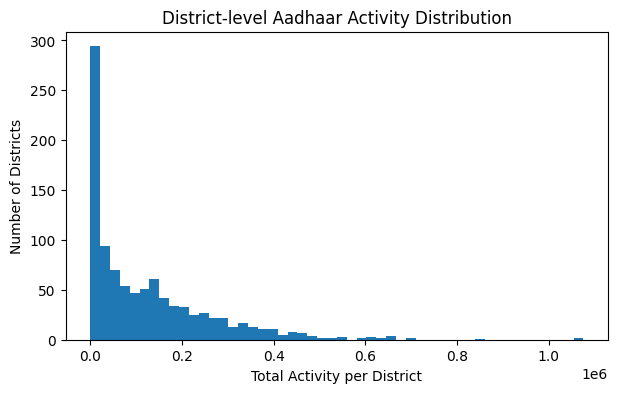

In [50]:
plt.figure(figsize=(7,4))
plt.hist(district_activity, bins=50)
plt.title("District-level Aadhaar Activity Distribution")
plt.xlabel("Total Activity per District")
plt.ylabel("Number of Districts")
plt.show()


In [51]:
pincode_activity = (
    Aadhaar_df.groupby('pincode')['total_activity']
    .sum()
    .sort_values(ascending=False)
)
pincode_activity.head(10)


pincode
110094    190580
244001    189541
110059    183169
202001    152776
247001    147476
283203    145935
431001    134948
244901    128143
110086    124694
421302    119141
Name: total_activity, dtype: int64

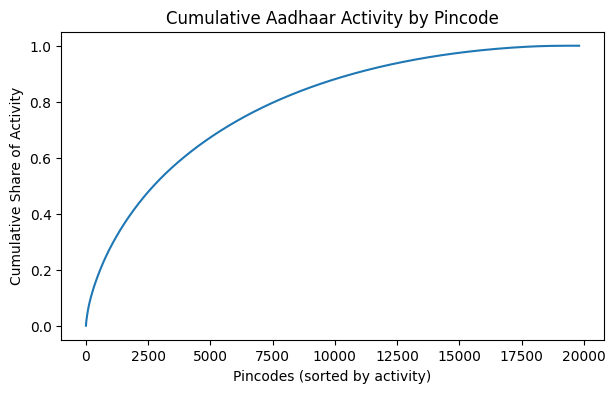

In [52]:
plt.figure(figsize=(7,4))
plt.plot(
    pincode_activity.values.cumsum() / pincode_activity.sum()
)
plt.title("Cumulative Aadhaar Activity by Pincode")
plt.xlabel("Pincodes (sorted by activity)")
plt.ylabel("Cumulative Share of Activity")
plt.show()


In [53]:
Aadhaar_df[['total_activity','pincode_avg_activity']].corr()


,total_activity,pincode_avg_activity
total_activity,1.00000,0.26291
pincode_avg_activity,0.26291,1.00000


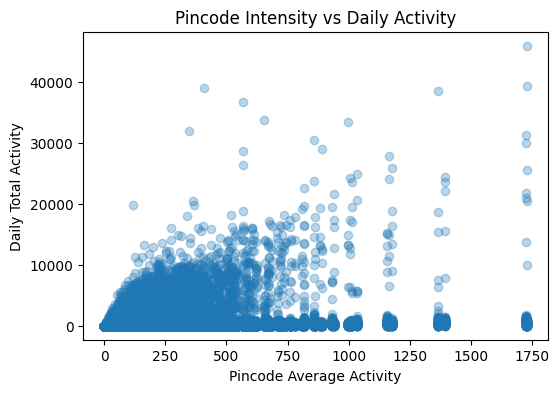

In [54]:
plt.figure(figsize=(6,4))
plt.scatter(
    Aadhaar_df['pincode_avg_activity'],
    Aadhaar_df['total_activity'],
    alpha=0.3
)
plt.xlabel("Pincode Average Activity")
plt.ylabel("Daily Total Activity")
plt.title("Pincode Intensity vs Daily Activity")
plt.show()


In [55]:
Aadhaar_df['pincode_bucket'] = pd.qcut(
    Aadhaar_df['pincode_avg_activity'],
    q=4,
    labels=['Low','Medium','High','Very High']
)


In [56]:
Aadhaar_df.groupby('pincode_bucket')['total_activity'].mean()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21432\1968648946.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Aadhaar_df.groupby('pincode_bucket')['total_activity'].mean()


pincode_bucket
Low            9.685950
Medium        22.459636
High          44.833405
Very High    139.038704
Name: total_activity, dtype: float64

In [57]:
Aadhaar_df[['enrollment_total','demographic_total','biometric_total']].sum()


enrollment_total      5428420
demographic_total    49250172
biometric_total      69636596
dtype: int64

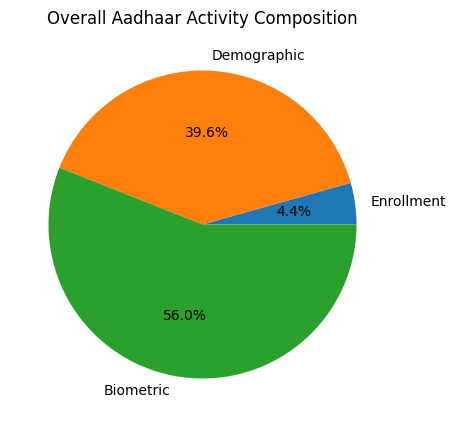

In [58]:
plt.figure(figsize=(5,5))
Aadhaar_df[['enrollment_total','demographic_total','biometric_total']].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Enrollment','Demographic','Biometric']
)
plt.title("Overall Aadhaar Activity Composition")
plt.ylabel("")
plt.show()


In [59]:
monthly_composition = Aadhaar_df.groupby('month')[
    ['enrollment_total','demographic_total','biometric_total']
].sum()


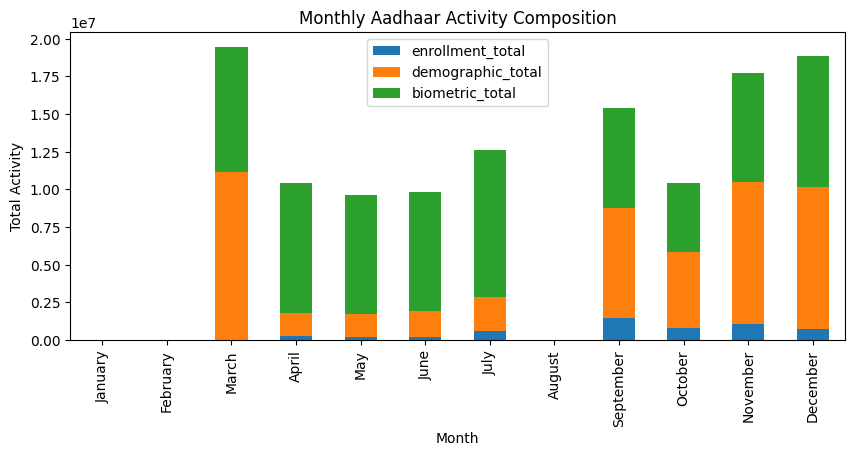

In [60]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_composition = monthly_composition.reindex(month_order)

monthly_composition.plot(
    kind='bar',
    stacked=True,
    figsize=(10,4)
)
plt.title("Monthly Aadhaar Activity Composition")
plt.xlabel("Month")
plt.ylabel("Total Activity")
plt.show()


In [61]:
weekday_comp = Aadhaar_df.groupby('weekday_name')[
    ['enrollment_total','demographic_total','biometric_total']
].mean()


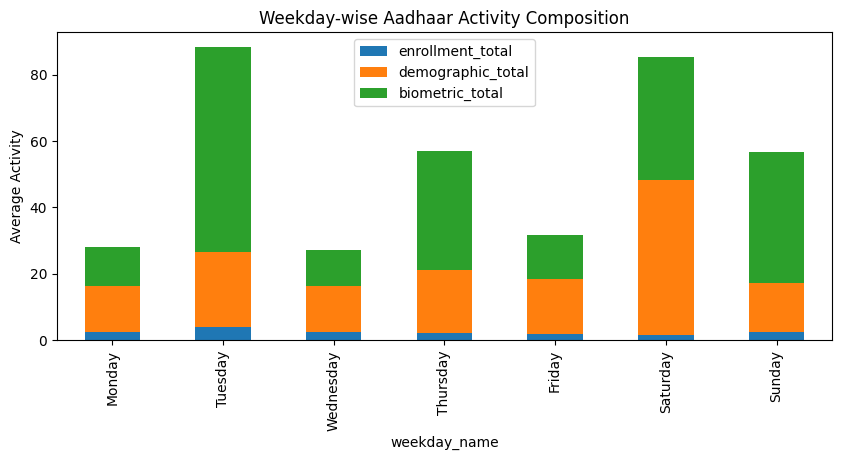

In [62]:
weekday_order = [
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]

weekday_comp = weekday_comp.reindex(weekday_order)

weekday_comp.plot(
    kind='bar',
    stacked=True,
    figsize=(10,4)
)
plt.title("Weekday-wise Aadhaar Activity Composition")
plt.ylabel("Average Activity")
plt.show()


In [63]:
state_comp = Aadhaar_df.groupby('state')[
    ['enrollment_total','demographic_total','biometric_total']
].sum()


In [64]:
state_comp_share = state_comp.div(state_comp.sum(axis=1), axis=0)
state_comp_share.head()


,enrollment_total,demographic_total,biometric_total
state,,,
andaman and nicobar islands,0.017958,0.254648,0.727394
andhra pradesh,0.020803,0.374001,0.605196
arunachal pradesh,0.038381,0.321989,0.639630
assam,0.103436,0.454990,0.441574
bihar,0.059060,0.466438,0.474502


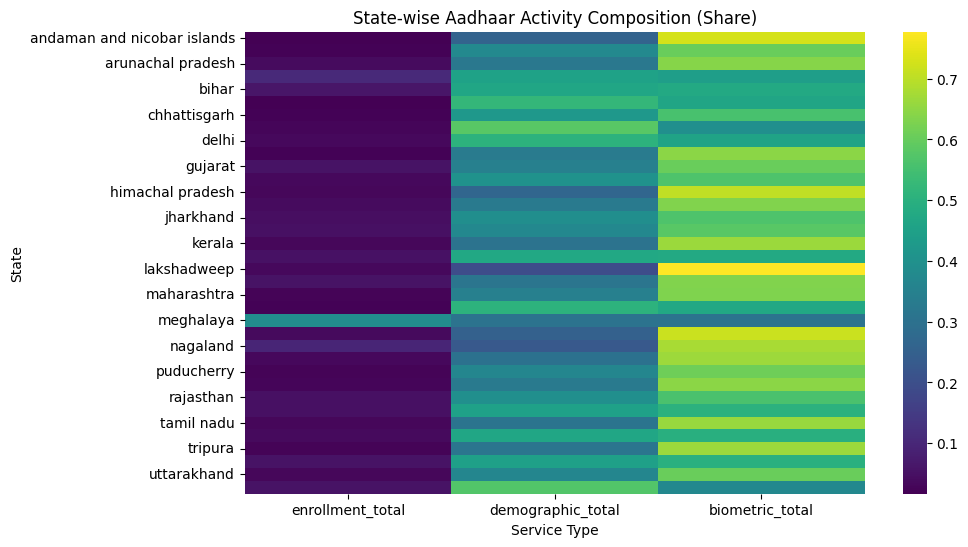

In [65]:
plt.figure(figsize=(10,6))
sns.heatmap(state_comp_share, cmap='viridis')
plt.title("State-wise Aadhaar Activity Composition (Share)")
plt.xlabel("Service Type")
plt.ylabel("State")
plt.show()


In [66]:
pincode_comp = Aadhaar_df.groupby('pincode_bucket')[
    ['enrollment_total','demographic_total','biometric_total']
].mean()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21432\1494581321.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pincode_comp = Aadhaar_df.groupby('pincode_bucket')[


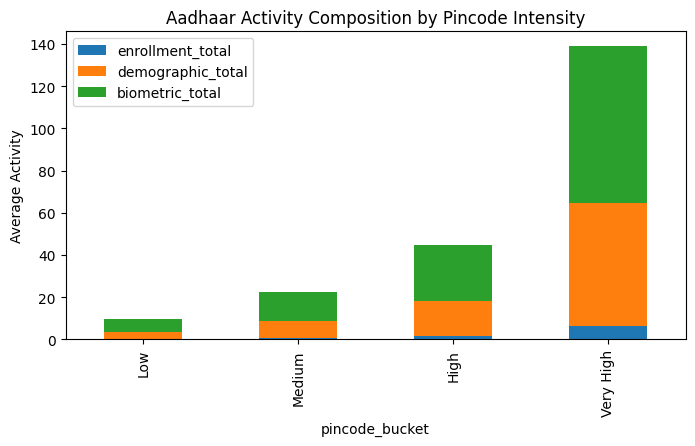

In [67]:
pincode_comp.plot(
    kind='bar',
    stacked=True,
    figsize=(8,4)
)
plt.title("Aadhaar Activity Composition by Pincode Intensity")
plt.ylabel("Average Activity")
plt.show()


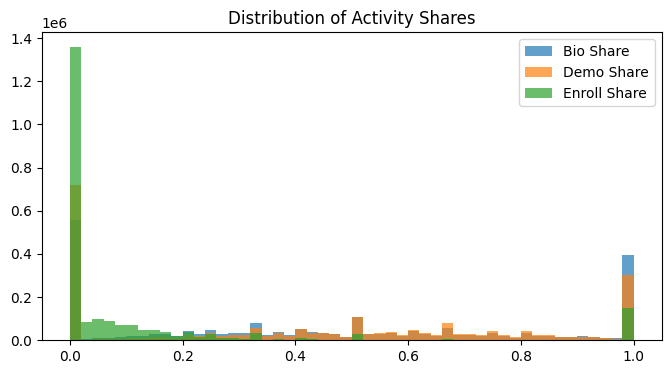

In [68]:
plt.figure(figsize=(8,4))
plt.hist(Aadhaar_df['bio_share'], bins=50, alpha=0.7, label='Bio Share')
plt.hist(Aadhaar_df['demo_share'], bins=50, alpha=0.7, label='Demo Share')
plt.hist(Aadhaar_df['enroll_share'], bins=50, alpha=0.7, label='Enroll Share')
plt.legend()
plt.title("Distribution of Activity Shares")
plt.show()


In [69]:
Aadhaar_df[['child_activity','adult_activity']].sum()


child_activity    5260315
adult_activity     168105
dtype: int64

In [70]:
age_share = Aadhaar_df[['child_activity','adult_activity']].sum()
age_share / age_share.sum()


child_activity    0.969032
adult_activity    0.030968
dtype: float64

In [71]:
daily_age_trend = Aadhaar_df.groupby('date')[
    ['child_activity','adult_activity']
].sum()


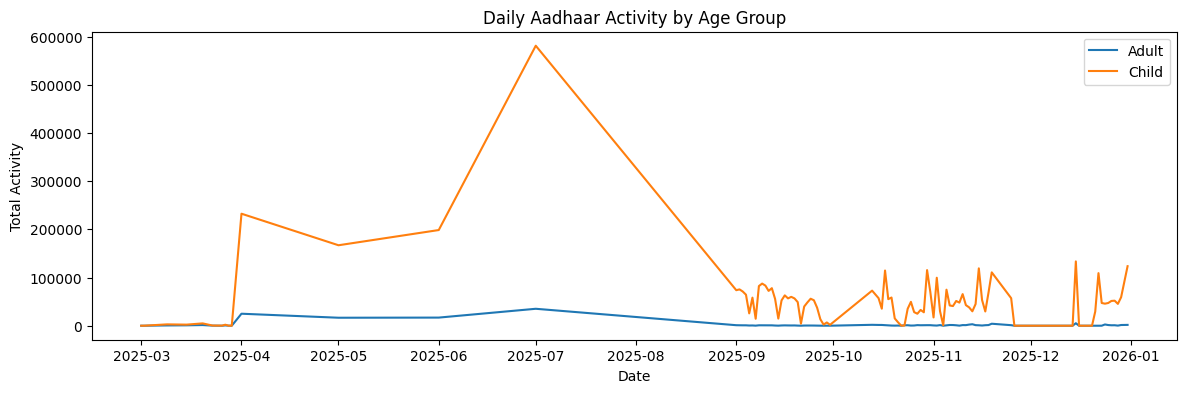

In [72]:
plt.figure(figsize=(14,4))
plt.plot(daily_age_trend['adult_activity'], label='Adult')
plt.plot(daily_age_trend['child_activity'], label='Child')
plt.legend()
plt.title("Daily Aadhaar Activity by Age Group")
plt.xlabel("Date")
plt.ylabel("Total Activity")
plt.show()


In [73]:
monthly_age = Aadhaar_df.groupby('month')[
    ['child_activity','adult_activity']
].sum()


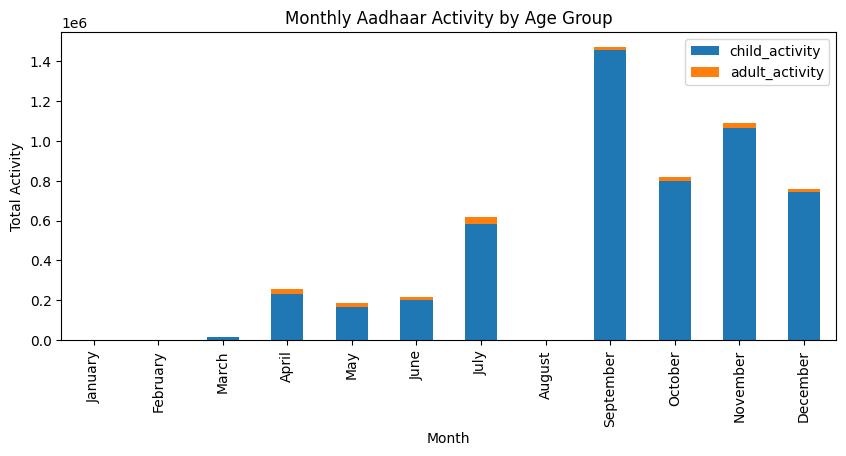

In [74]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_age = monthly_age.reindex(month_order)

monthly_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10,4)
)
plt.title("Monthly Aadhaar Activity by Age Group")
plt.xlabel("Month")
plt.ylabel("Total Activity")
plt.show()


In [75]:
state_age = Aadhaar_df.groupby('state')[
    ['child_activity','adult_activity']
].sum()


In [76]:
state_age_share = state_age.div(state_age.sum(axis=1), axis=0)
state_age_share.head()


,child_activity,adult_activity
state,,
andaman and nicobar islands,1.000000,0.000000
andhra pradesh,0.988292,0.011708
arunachal pradesh,0.965239,0.034761
assam,0.900620,0.099380
bihar,0.980465,0.019535


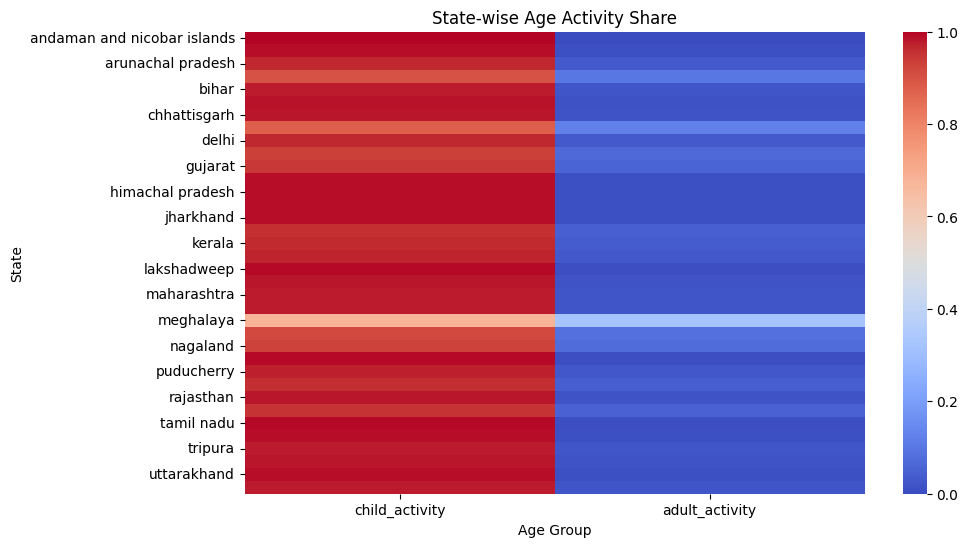

In [77]:
plt.figure(figsize=(10,6))
sns.heatmap(state_age_share, cmap='coolwarm')
plt.title("State-wise Age Activity Share")
plt.xlabel("Age Group")
plt.ylabel("State")
plt.show()


In [78]:
Aadhaar_df.columns

Index(['date', 'state', 'district', 'pincode', 'month', 'age_0_5', 'age_5_17',
       'age_18_greater', 'demo_age_5_17', 'demo_age_17_', 'bio_age_5_17',
       'bio_age_17_', 'total_activity', 'day', 'weekday', 'weekday_name',
       'is_weekend', 'month_num', 'quarter', 'enrollment_total',
       'demographic_total', 'biometric_total', 'bio_share', 'demo_share',
       'enroll_share', 'child_activity', 'adult_activity',
       'pincode_avg_activity', 'lag_1_day', 'lag_7_day', 'rolling_7_mean',
       'high_activity_flag', 'state_code', 'district_code', 'pincode_bucket'],
      dtype='object')

In [79]:
age_service = pd.DataFrame({
    'Adult': [
        Aadhaar_df['bio_age_17_'].sum(),
        Aadhaar_df['demo_age_17_'].sum(),
        Aadhaar_df['age_18_greater'].sum()
    ],
    'Child': [
        Aadhaar_df['bio_age_5_17'].sum(),
        Aadhaar_df['demo_age_5_17'].sum(),
        Aadhaar_df['age_0_5'].sum() + Aadhaar_df['age_5_17'].sum()
    ]
}, index=['Biometric','Demographic','Enrollment'])

age_service


,Adult,Child
Biometric,35443389,34193207
Demographic,44390829,4859343
Enrollment,168105,5260315


In [80]:
Aadhaar_df[['total_activity','lag_1_day']].corr()


,total_activity,lag_1_day
total_activity,1.000000,0.526472
lag_1_day,0.526472,1.000000


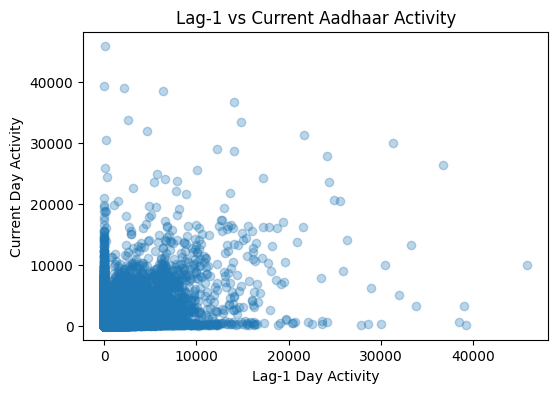

In [81]:
plt.figure(figsize=(6,4))
plt.scatter(
    Aadhaar_df['lag_1_day'],
    Aadhaar_df['total_activity'],
    alpha=0.3
)
plt.xlabel("Lag-1 Day Activity")
plt.ylabel("Current Day Activity")
plt.title("Lag-1 vs Current Aadhaar Activity")
plt.show()


In [82]:
Aadhaar_df[['total_activity','lag_7_day']].corr()


,total_activity,lag_7_day
total_activity,1.000000,0.020376
lag_7_day,0.020376,1.000000


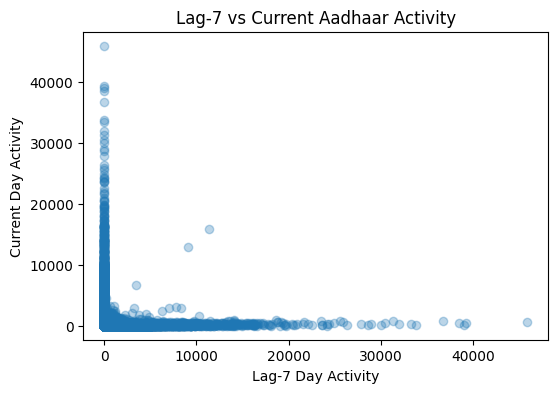

In [83]:
plt.figure(figsize=(6,4))
plt.scatter(
    Aadhaar_df['lag_7_day'],
    Aadhaar_df['total_activity'],
    alpha=0.3
)
plt.xlabel("Lag-7 Day Activity")
plt.ylabel("Current Day Activity")
plt.title("Lag-7 vs Current Aadhaar Activity")
plt.show()


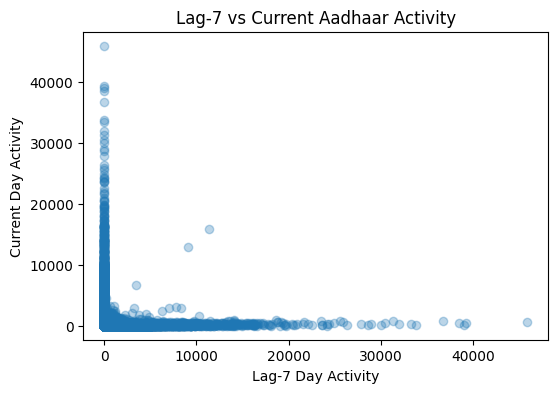

In [84]:
plt.figure(figsize=(6,4))
plt.scatter(
    Aadhaar_df['lag_7_day'],
    Aadhaar_df['total_activity'],
    alpha=0.3
)
plt.xlabel("Lag-7 Day Activity")
plt.ylabel("Current Day Activity")
plt.title("Lag-7 vs Current Aadhaar Activity")
plt.show()


In [85]:
Aadhaar_df[['total_activity','rolling_7_mean']].corr()


,total_activity,rolling_7_mean
total_activity,1.000000,0.059522
rolling_7_mean,0.059522,1.000000


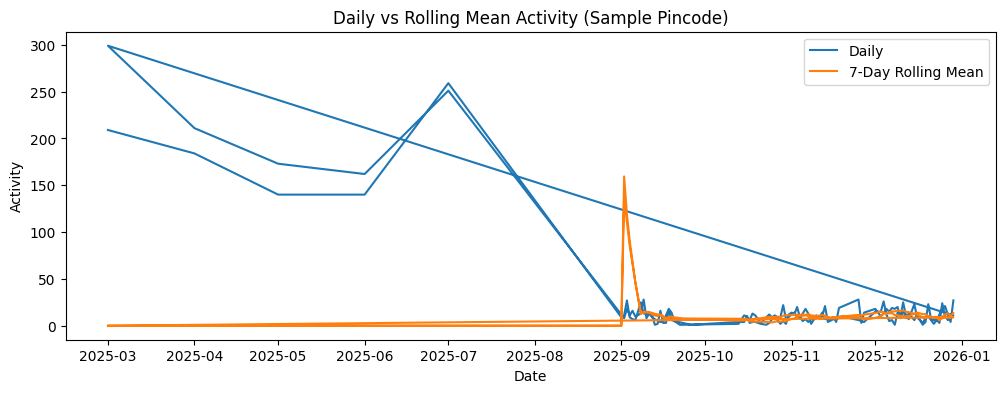

In [86]:
sample_pincode = Aadhaar_df['pincode'].iloc[0]

sample_df = Aadhaar_df[Aadhaar_df['pincode'] == sample_pincode]

plt.figure(figsize=(12,4))
plt.plot(sample_df['date'], sample_df['total_activity'], label='Daily')
plt.plot(sample_df['date'], sample_df['rolling_7_mean'], label='7-Day Rolling Mean')
plt.legend()
plt.title("Daily vs Rolling Mean Activity (Sample Pincode)")
plt.xlabel("Date")
plt.ylabel("Activity")
plt.show()


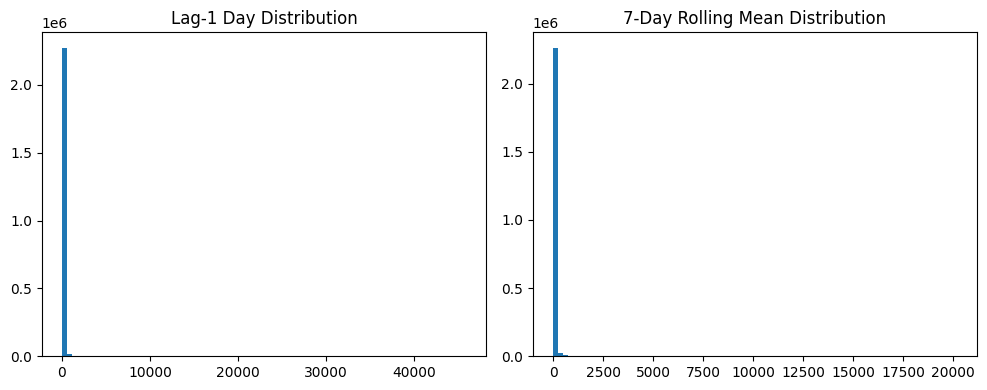

In [87]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(Aadhaar_df['lag_1_day'].dropna(), bins=80)
plt.title("Lag-1 Day Distribution")

plt.subplot(1,2,2)
plt.hist(Aadhaar_df['rolling_7_mean'].dropna(), bins=80)
plt.title("7-Day Rolling Mean Distribution")

plt.tight_layout()
plt.show()


In [88]:
rolling_corr = (
    Aadhaar_df[['total_activity','lag_1_day']]
    .dropna()
    .rolling(30)
    .corr()
    .iloc[0::2, -1]
)


ValueError: setting an array element with a sequence.

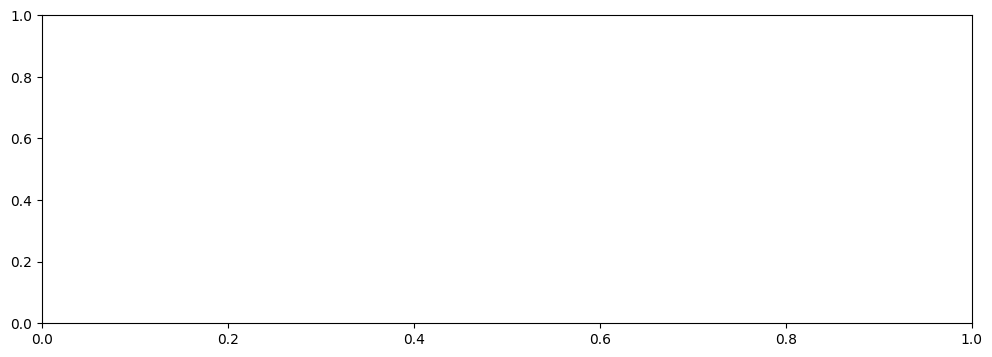

In [89]:
plt.figure(figsize=(12,4))
plt.plot(rolling_corr)
plt.title("Rolling Correlation: Total Activity vs Lag-1")
plt.xlabel("Time")
plt.ylabel("Correlation")
plt.show()


In [ ]:
Aadhaar_df.groupby('high_activity_flag')[
    ['lag_1_day','rolling_7_mean']
].mean()


,lag_1_day,rolling_7_mean
high_activity_flag,,
0,42.405566,37.000404
1,1189.877576,37.296564


In [ ]:
Aadhaar_df['total_activity'].describe(percentiles=[0.95, 0.99])


count    2.302107e+06
mean     5.400061e+01
std      2.809834e+02
min      1.000000e+00
50%      1.200000e+01
95%      1.710000e+02
99%      7.080000e+02
max      4.586100e+04
Name: total_activity, dtype: float64

In [ ]:
threshold = Aadhaar_df['total_activity'].quantile(0.99)

Aadhaar_df['anomaly_high'] = (Aadhaar_df['total_activity'] > threshold).astype(int)


In [ ]:
Aadhaar_df['anomaly_high'].value_counts(normalize=True)


anomaly_high
0    0.990008
1    0.009992
Name: proportion, dtype: float64

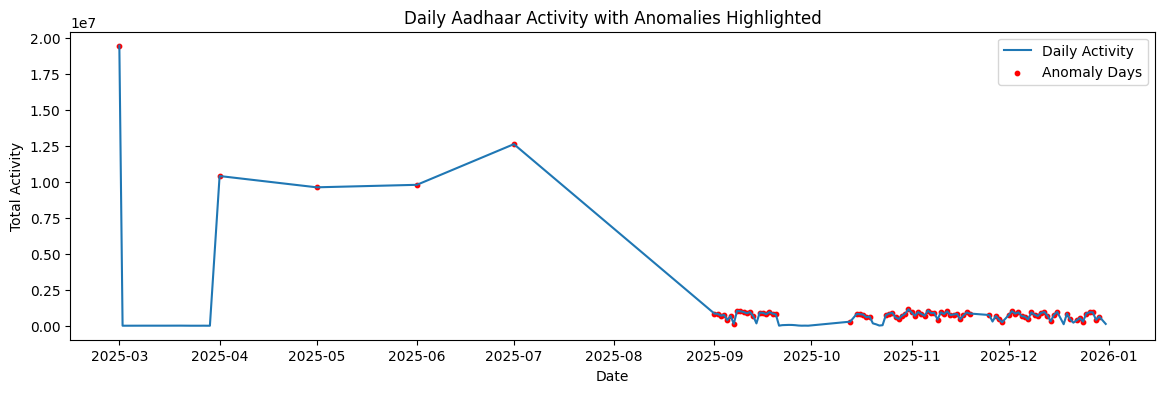

In [ ]:
daily_activity = Aadhaar_df.groupby('date')['total_activity'].sum()
daily_anomaly = Aadhaar_df.groupby('date')['anomaly_high'].max()

plt.figure(figsize=(14,4))
plt.plot(daily_activity, label='Daily Activity')
plt.scatter(
    daily_activity[daily_anomaly == 1].index,
    daily_activity[daily_anomaly == 1],
    color='red',
    label='Anomaly Days',
    s=10
)
plt.legend()
plt.title("Daily Aadhaar Activity with Anomalies Highlighted")
plt.xlabel("Date")
plt.ylabel("Total Activity")
plt.show()


In [ ]:
Aadhaar_df['deviation'] = (
    Aadhaar_df['total_activity'] - Aadhaar_df['rolling_7_mean']
)


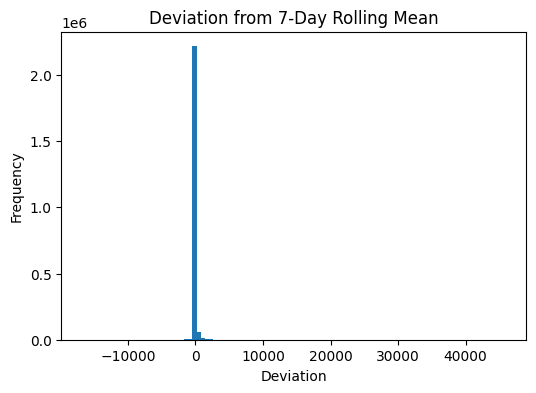

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(Aadhaar_df['deviation'].dropna(), bins=100)
plt.title("Deviation from 7-Day Rolling Mean")
plt.xlabel("Deviation")
plt.ylabel("Frequency")
plt.show()


In [ ]:
Aadhaar_df['rolling_std'] = Aadhaar_df.groupby(
    ['state','district','pincode']
)['total_activity'].transform(lambda x: x.rolling(7).std())

Aadhaar_df['z_score'] = (
    Aadhaar_df['total_activity'] - Aadhaar_df['rolling_7_mean']
) / Aadhaar_df['rolling_std']


In [ ]:
Aadhaar_df['anomaly_z'] = (Aadhaar_df['z_score'].abs() > 3).astype(int)


In [ ]:
Aadhaar_df['anomaly_z'].value_counts()


anomaly_z
0    2302107
Name: count, dtype: int64

In [ ]:
Aadhaar_df.groupby('anomaly_z')[
    ['total_activity','lag_1_day','rolling_7_mean']
].mean()


,total_activity,lag_1_day,rolling_7_mean
anomaly_z,,,
0,54.000612,53.870781,37.003363


In [ ]:
Aadhaar_df[Aadhaar_df['anomaly_z'] == 1] \
    .groupby('state')['total_activity'] \
    .count() \
    .sort_values(ascending=False) \
    .head(10)


Series([], Name: total_activity, dtype: int64)

In [ ]:
target = 'total_activity'


In [ ]:
corr_with_target = (
    Aadhaar_df.corr(numeric_only=True)[target]
    .sort_values(ascending=False)
)

corr_with_target


total_activity          1.000000
deviation               0.905512
demographic_total       0.878485
demo_age_17_            0.873336
biometric_total         0.847053
demo_age_5_17           0.810454
bio_age_17_             0.809161
bio_age_5_17            0.792224
high_activity_flag      0.650152
anomaly_high            0.650152
lag_1_day               0.526472
age_0_5                 0.409238
child_activity          0.390765
enrollment_total        0.385897
age_5_17                0.317807
rolling_std             0.274135
pincode_avg_activity    0.262910
z_score                 0.261321
adult_activity          0.136445
age_18_greater          0.136445
rolling_7_mean          0.059522
bio_share               0.056594
is_weekend              0.039627
weekday                 0.020611
lag_7_day               0.020376
state_code              0.003823
district_code          -0.005891
demo_share             -0.015706
pincode                -0.040744
enroll_share           -0.057747
day       

In [ ]:
important_features = [
    'total_activity',
    'rolling_7_mean',
    'lag_1_day',
    'lag_7_day',
    'biometric_total',
    'demographic_total',
    'enrollment_total',
    'adult_activity',
    'child_activity',
    'pincode_avg_activity',
    'bio_share',
    'demo_share',
    'enroll_share'
]


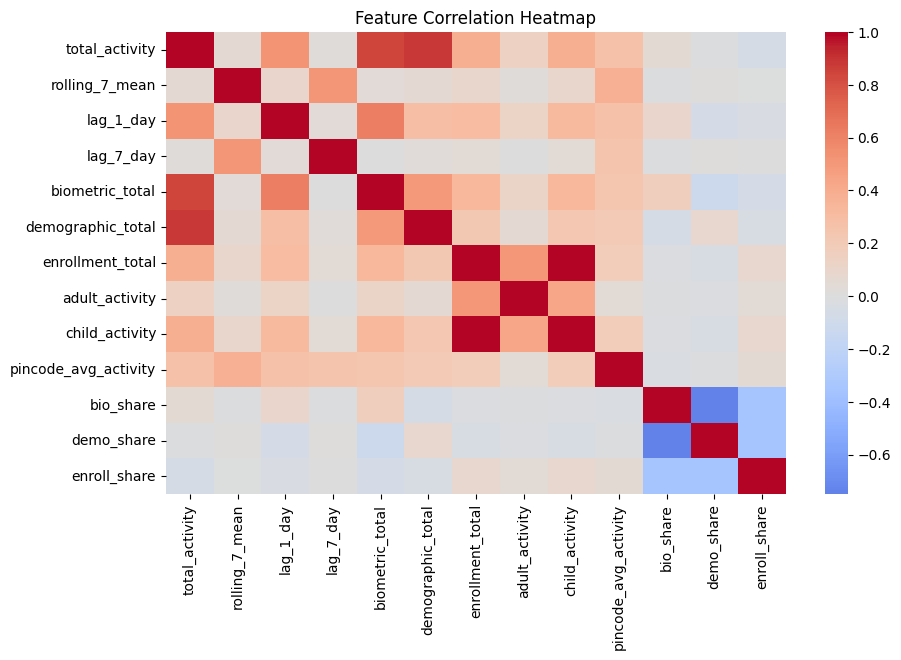

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(
    Aadhaar_df[important_features].corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
Aadhaar_df[['biometric_total','bio_share','total_activity']].corr()


,biometric_total,bio_share,total_activity
biometric_total,1.000000,0.171743,0.847053
bio_share,0.171743,1.000000,0.056594
total_activity,0.847053,0.056594,1.000000


In [ ]:
Aadhaar_df[['enrollment_total','enroll_share','child_activity']].corr()


,enrollment_total,enroll_share,child_activity
enrollment_total,1.000000,0.083885,0.995833
enroll_share,0.083885,1.000000,0.083481
child_activity,0.995833,0.083481,1.000000


In [ ]:
Aadhaar_df.groupby('anomaly_z')[
    ['rolling_7_mean','lag_1_day','pincode_avg_activity']
].mean()


,rolling_7_mean,lag_1_day,pincode_avg_activity
anomaly_z,,,
0,37.003363,53.870781,54.000612


In [ ]:
Aadhaar_df[important_features].var().sort_values(ascending=False)


total_activity          78951.690551
lag_1_day               78937.606414
lag_7_day               78909.850059
demographic_total       28532.121378
biometric_total         21589.481010
rolling_7_mean          16465.185556
pincode_avg_activity     5457.258579
enrollment_total          444.277316
child_activity            402.861949
adult_activity              4.538661
bio_share                   0.132075
demo_share                  0.132016
enroll_share                0.066230
dtype: float64

In [ ]:
final_features = [
    'rolling_7_mean','lag_1_day','lag_7_day',
    'pincode_avg_activity',
    'biometric_total','demographic_total',
    'adult_activity','bio_share',
    'weekday','month_num'
]

X = Aadhaar_df[final_features]
y = Aadhaar_df['total_activity']


In [ ]:
Aadhaar_df.to_csv("fEDA_aadhaar_data.csv", index=False)